QObject::moveToThread: Current thread (0x2237cf0) is not the object's thread (0x24120e0).
Cannot move to target thread (0x2237cf0)

QObject::moveToThread: Current thread (0x2237cf0) is not the object's thread (0x24120e0).
Cannot move to target thread (0x2237cf0)

QObject::moveToThread: Current thread (0x2237cf0) is not the object's thread (0x24120e0).
Cannot move to target thread (0x2237cf0)

QObject::moveToThread: Current thread (0x2237cf0) is not the object's thread (0x24120e0).
Cannot move to target thread (0x2237cf0)

QObject::moveToThread: Current thread (0x2237cf0) is not the object's thread (0x24120e0).
Cannot move to target thread (0x2237cf0)

QObject::moveToThread: Current thread (0x2237cf0) is not the object's thread (0x24120e0).
Cannot move to target thread (0x2237cf0)

QObject::moveToThread: Current thread (0x2237cf0) is not the object's thread (0x24120e0).
Cannot move to target thread (0x2237cf0)

QObject::moveToThread: Current thread (0x2237cf0) is not the object's thread

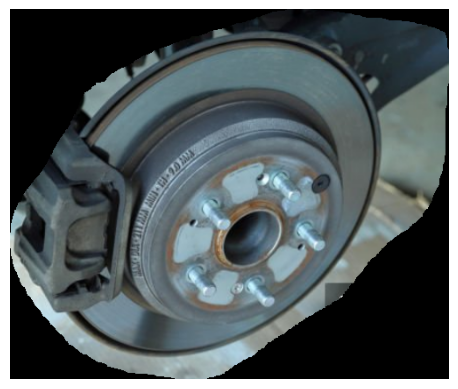

Enter label for the cropped image:  rotor


Cropped image saved as: /home/natsu/MechAI/rotor.png


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Global variables
drawing = False  # True if the mouse is pressed
points = []  # List to store points for freehand drawing

def draw_freehand(event, x, y, flags, param):
    global drawing, points, img, img_copy

    # Start drawing on left mouse button press
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        points = [(x, y)]  # Start new path
        img_copy = img.copy()  # Copy of the image to reset as needed

    # Add points to path on mouse movement
    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            img_copy = img.copy()  # Reset to original image for a fresh redraw
            points.append((x, y))
            for i in range(1, len(points)):
                cv2.line(img_copy, points[i - 1], points[i], (0, 255, 0), 2)  # Draw line segments
            cv2.imshow("Image", img_copy)  # Show updated drawing in real-time

    # Stop drawing on left mouse button release and close shape
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        points.append((x, y))
        cv2.line(img_copy, points[0], points[-1], (0, 255, 0), 2)  # Connect end to start
        cv2.imshow("Image", img_copy)  # Show the final closed shape

def crop_and_save_freehand(image_path, save_dir):
    global img, img_copy
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Unable to load image.")
        return
    img_copy = img.copy()  # Initialize the image copy

    # Show image and set mouse callback for drawing
    cv2.imshow("Image", img_copy)
    cv2.setMouseCallback("Image", draw_freehand)

    # Wait until the user completes the shape
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # Create a mask from the points
    mask = np.zeros_like(img, dtype=np.uint8)
    if len(points) > 2:
        points_array = np.array(points, dtype=np.int32)
        cv2.fillPoly(mask, [points_array], (255, 255, 255))

        # Apply mask to crop region of interest
        cropped_img = cv2.bitwise_and(img, mask)
        x, y, w, h = cv2.boundingRect(points_array)  # Bounding box of the polygon
        cropped_img = cropped_img[y:y+h, x:x+w]

        # Show cropped image
        plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

        # Get label from user and save cropped image
        label = input("Enter label for the cropped image: ")
        save_path = f"{save_dir}/{label}.png"
        cv2.imwrite(save_path, cropped_img)
        print(f"Cropped image saved as: {save_path}")
    else:
        print("Shape not drawn. Please draw a complete shape next time.")

# Example usage
# Replace 'path/to/image.jpg' and 'path/to/save_dir' with actual paths
crop_and_save_freehand('/home/natsu/MechAI/GP1.png', '/home/natsu/MechAI')
